In [1]:
from datasets import load_dataset
datasets = load_dataset("community-datasets/yahoo_answers_topics", num_proc=8)

In [2]:
datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'topic', 'question_title', 'question_content', 'best_answer'],
        num_rows: 1400000
    })
    test: Dataset({
        features: ['id', 'topic', 'question_title', 'question_content', 'best_answer'],
        num_rows: 60000
    })
})

In [3]:
datasets = datasets.filter(lambda x: len(x["question_title"]) > 0)

In [4]:
datasets.set_format("pandas")
df = datasets["train"][:]
df

,id,topic,question_title,question_content,best_answer
0,0,4,why doesn't an optical mouse work on a glass t...,or even on some surfaces?,Optical mice use an LED and a camera to rapidl...
1,1,5,What is the best off-road motorcycle trail ?,long-distance trail throughout CA,i hear that the mojave road is amazing!<br />\...
2,2,2,What is Trans Fat? How to reduce that?,I heard that tras fat is bad for the body. Wh...,Trans fats occur in manufactured foods during ...
3,3,6,How many planes Fedex has?,I heard that it is the largest airline in the ...,according to the www.fedex.com web site:\nAir ...
4,4,6,"In the san francisco bay area, does it make se...",the prices of rent and the price of buying doe...,renting vs buying depends on your goals. <br /...
...,...,...,...,...,...
1399995,1399995,2,do all these ads on tv of yoko etc regarding h...,,I increased my height 2 feet afterwards so yes...
1399996,1399996,6,Ways to sell your video games?,Like if you want to sell your video games how ...,"ebay, electronic boutique, babbages or flea ma..."
1399997,1399997,2,is it normal to have nots in your breast or bo...,,It can be normal as long as they are not cance...
1399998,1399998,0,Who can speak Hindi??,If you can write it here!!,Main hindi bol sakti hoon.kahiye.


In [5]:
lens = [len(question) for question in df["question_title"]]


<Axes: ylabel='Count'>

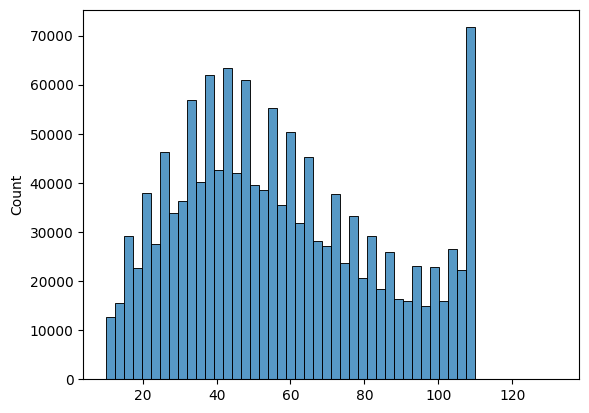

In [6]:
import seaborn as sns
sns.histplot(lens, bins=50)

In [7]:
import numpy as np
np.mean(lens)

np.float64(57.17476071428572)

In [8]:
df["topic"].value_counts()

topic
4    140000
5    140000
2    140000
6    140000
1    140000
7    140000
3    140000
8    140000
9    140000
0    140000
Name: count, dtype: int64

In [9]:
datasets.reset_format()

In [10]:
datasets = datasets.filter(lambda x: (len(x["question_title"]) >= 30 and len(x["question_title"]) <=60) or len(x["question_title"]) >= 100)

In [11]:
datasets.set_format("pandas")
df = datasets["train"][:]
df["topic"].value_counts()

topic
5    79022
7    76420
6    76016
4    75861
3    75324
2    75062
1    74011
0    74007
9    73746
8    71892
Name: count, dtype: int64

In [12]:
datasets.reset_format()

In [13]:
unique_questions = datasets["train"].unique(column="question_title")

In [14]:
datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'topic', 'question_title', 'question_content', 'best_answer'],
        num_rows: 751361
    })
    test: Dataset({
        features: ['id', 'topic', 'question_title', 'question_content', 'best_answer'],
        num_rows: 32156
    })
})

In [15]:
datasets["train"] = datasets["train"].shuffle(seed=42).select(range(50000))
datasets["test"] = datasets["test"].shuffle(seed=42).select(range(10000))

In [16]:
datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'topic', 'question_title', 'question_content', 'best_answer'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['id', 'topic', 'question_title', 'question_content', 'best_answer'],
        num_rows: 10000
    })
})

In [17]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model

model_ckpt = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=10)
model = model.to("cuda")
model

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight        

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

In [18]:
from peft import TaskType
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=8,
    target_modules=["query_proj", "value_proj"]
)

In [19]:
lora_model = get_peft_model(model,peft_config)

In [20]:
lora_model.print_trainable_parameters()


trainable params: 302,602 || all params: 184,732,436 || trainable%: 0.1638


In [21]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [22]:
def tokenize(batch):
    return tokenizer(batch["question_title"], truncation=True, max_length=256)

In [23]:
label_names = datasets["train"].features["topic"].names

In [24]:
label_names

['Society & Culture',
 'Science & Mathematics',
 'Health',
 'Education & Reference',
 'Computers & Internet',
 'Sports',
 'Business & Finance',
 'Entertainment & Music',
 'Family & Relationships',
 'Politics & Government']

In [25]:
label2id = {v:k for k,v in enumerate(label_names)}
id2label = {k:v for k,v in enumerate(label_names)}

In [26]:
datasets = datasets.rename_column(original_column_name="topic", new_column_name="label")

In [27]:
datasets=datasets.map(tokenize, batched=True)

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [28]:
from transformers import TrainingArguments
args = TrainingArguments(
    output_dir="../deberta-ft",
    per_device_eval_batch_size=16,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    eval_strategy="steps",
    eval_steps=200,
    logging_strategy="steps",
    logging_steps=200
    )

In [29]:
import evaluate
import numpy as np

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    accuracy = evaluate.load("accuracy")
    precision = evaluate.load("precision")
    recall = evaluate.load("recall")
    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision.compute(predictions=predictions, references=labels, zero_division=0, average="macro")["precision"],
        "recall": recall.compute(predictions=predictions, references=labels, zero_division=0, average="macro")["recall"]
    }

In [30]:
from transformers import Trainer
trainer = Trainer(
    args=args,
    model=lora_model,
    train_dataset=datasets["train"],
    eval_dataset=datasets["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [31]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall
200,2.498824,2.407358,0.101400,0.090209,0.101914
400,2.417791,2.356425,0.104600,0.111053,0.105118
600,2.376658,2.312731,0.106000,0.101263,0.104943
800,2.345716,2.309870,0.107000,0.097589,0.106434
1000,2.344238,2.305125,0.116900,0.116174,0.116400
1200,2.344734,2.299427,0.118800,0.120982,0.116926
1400,2.322626,2.301254,0.117000,0.128495,0.117505
1600,2.320474,2.298048,0.118800,0.140910,0.119582
1800,2.325474,2.294748,0.136100,0.143589,0.137778
2000,2.319007,2.290158,0.131400,0.156582,0.132595


TrainOutput(global_step=9375, training_loss=2.194804055989583, metrics={'train_runtime': 2357.6756, 'train_samples_per_second': 63.622, 'train_steps_per_second': 3.976, 'total_flos': 2183497905488640.0, 'train_loss': 2.194804055989583, 'epoch': 3.0})